# AdaBoost: regression and classification

In [7]:
from sklearn.datasets import make_regression, make_classification
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
Xreg, yreg = make_regression(n_samples=1000, n_features=6, n_informative=6, noise=0.1, random_state=0)
Xcls, ycls = make_classification(n_samples=1000, n_features=15, n_informative=10, n_redundant=2, n_classes=3, random_state=0)

## AdaBoost with regression trees

In [9]:
Xreg_train, Xreg_test, yreg_train, yreg_test = train_test_split(Xreg, yreg, train_size=0.8, random_state=0)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

In [10]:
def print_r2(model):
    r2 = r2_score(y_true=yreg_test, y_pred=model.predict(Xreg_test))
    print(f"The R2 on the test set is {r2*100:.2f}%")

def plot_predictions(model):
    fig, ax = plt.subplots(figsize=(8,8))
    sorted_y, sorted_X = zip(*sorted(zip(yreg_test, Xreg_test)))
    predictions = model.predict(sorted_X)
    ax.scatter(range(len(sorted_X)), sorted_y, label='Test points')
    ax.scatter(range(len(sorted_X)), predictions, label='Predictions')
    ax.set_xlabel(r'Training points ordered by label $y$', fontsize=14)
    ax.set_ylabel(r'Value of label $y$', fontsize=14)
    ax.set_title('Predictions on the test set', fontsize=14)
    ax.legend(fontsize=14)
    return fig, ax

In [11]:
adaboost = GridSearchCV(
    estimator=AdaBoostRegressor(
        base_estimator=DecisionTreeRegressor(random_state=0),
        random_state=0
    ),
    param_grid=dict(
        n_estimators=[200, 250, 300],
        base_estimator__max_depth=[5, 10, 15],
    ),
    cv=kfold
)
adaboost.fit(Xreg_train, yreg_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=AdaBoostRegressor(base_estimator=DecisionTreeRegressor(random_state=0),
                                         random_state=0),
             param_grid={'base_estimator__max_depth': [5, 10, 15],
                         'n_estimators': [200, 250, 300]})

In [12]:
adaboost.best_params_

{'base_estimator__max_depth': 15, 'n_estimators': 300}

In [13]:
print_r2(adaboost)

The R2 on the test set is 93.05%


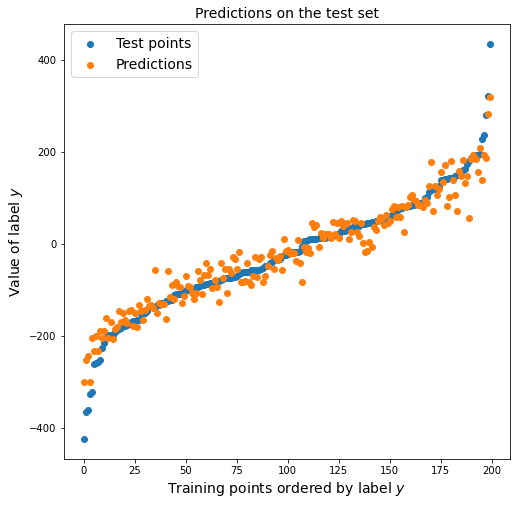

In [14]:
plot_predictions(adaboost);

## AdaBoost with classification trees

In [15]:
Xcls_train, Xcls_test, ycls_train, ycls_test = train_test_split(Xcls, ycls, train_size=0.8, stratify=ycls, random_state=0)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [16]:
def print_accuracy(model):
    acc = accuracy_score(y_true=ycls_test, y_pred=model.predict(Xcls_test), )
    print(f"The Accuracy on the test set is {acc*100:.3f}%")

def plot_confusion_matrix(model):
    cm = confusion_matrix(y_true=ycls_test, y_pred=model.predict(Xcls_test))
    fig, ax = plt.subplots(figsize=(8,8))
    sns.heatmap(data=cm, annot=True, square=True, linewidths=1, cbar=False, ax=ax)
    ax.set_xlabel('Predicted value', fontsize=14)
    ax.set_ylabel('True value', fontsize=14)
    ax.set_title('Confusion matrix', fontsize=14)
    return fig, ax

In [17]:
adaboost = GridSearchCV(
    estimator=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(), random_state=0),
    param_grid=dict(
        n_estimators=[200, 250, 300],
        base_estimator__max_depth=[5, 10, 15],
    ),
    cv=kfold
)
adaboost.fit(Xcls_train, ycls_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(),
                                          random_state=0),
             param_grid={'base_estimator__max_depth': [5, 10, 15],
                         'n_estimators': [200, 250, 300]})

In [18]:
adaboost.best_params_

{'base_estimator__max_depth': 10, 'n_estimators': 250}

In [19]:
print_accuracy(adaboost)

The Accuracy on the test set is 88.500%


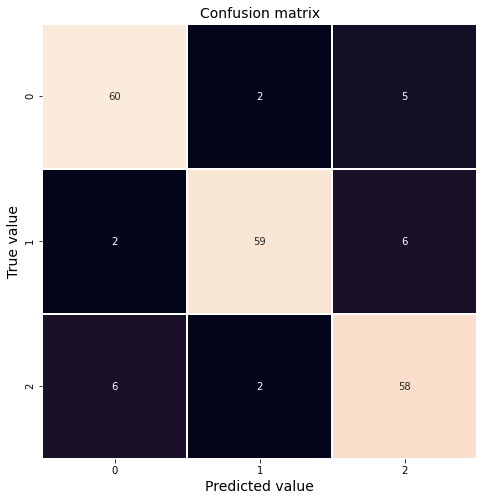

In [20]:
plot_confusion_matrix(adaboost);